# Lesson 5 — Kernels and Similarity Functions

In Lesson 4 we learned that a Gaussian Process makes predictions by computing **conditional distributions**. But how does a GP decide which points are "related" to each other?

The answer is the **kernel function** (also called a covariance function):

> k(x, x') = how similar are the outputs f(x) and f(x') expected to be?

Core intuition: **nearby inputs → similar outputs**. The kernel formalises this.

By the end of this lesson you will:
1. Implement the RBF kernel from scratch
2. Understand how length-scale controls function smoothness
3. Know the difference between RBF, Matern, and Linear kernels
4. Sample random functions from a GP prior
5. Understand why neural networks don't need a kernel (and why that helps in high dimensions)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
rng = np.random.default_rng(RANDOM_SEED)

print('Imports OK')

Imports OK


---
## Part 1 — What is a Kernel?

A kernel is a function that takes two inputs and returns a single number — their similarity.

The most common kernel is the **RBF (Radial Basis Function)** kernel, also called the Squared Exponential:

$$k(x, x') = \sigma^2 \exp\!\left(-\frac{(x - x')^2}{2l^2}\right)$$

- When x = x': k = σ² (maximum similarity)
- As |x − x'| grows: k → 0 (no similarity)
- **l** (length-scale): controls how fast similarity drops with distance

In [3]:
def rbf(X1, X2, length_scale=1.0, signal_var=1.0):
    """RBF kernel — works for 1D or multi-dimensional inputs."""
    X1 = np.atleast_2d(X1)
    X2 = np.atleast_2d(X2)
    diff    = X1[:, None, :] - X2[None, :, :]   # shape (n, m, d)
    sq_dist = np.sum(diff ** 2, axis=-1)          # shape (n, m)
    return signal_var * np.exp(-0.5 * sq_dist / length_scale**2)

# Check a few values — the pattern should match your intuition
pairs = [(0.5, 0.5), (0.5, 0.6), (0.5, 0.8), (0.5, 1.0)]
print('RBF kernel values (l=0.3, σ²=1):')  
print(f'{"x":>5}  {"x\':":>6}  {"k(x,x\')":>10}  note')
print('-' * 40)
for x1, x2 in pairs:
    k = rbf(np.array([[x1]]), np.array([[x2]]), length_scale=0.3).item()
    note = 'same point' if x1 == x2 else f'dist={abs(x1-x2):.1f}'
    print(f'{x1:>5}  {x2:>6}  {k:>10.4f}  {note}')

RBF kernel values (l=0.3, σ²=1):
    x     x':     k(x,x')  note
----------------------------------------
  0.5     0.5      1.0000  same point
  0.5     0.6      0.9460  dist=0.1
  0.5     0.8      0.6065  dist=0.3
  0.5     1.0      0.2494  dist=0.5


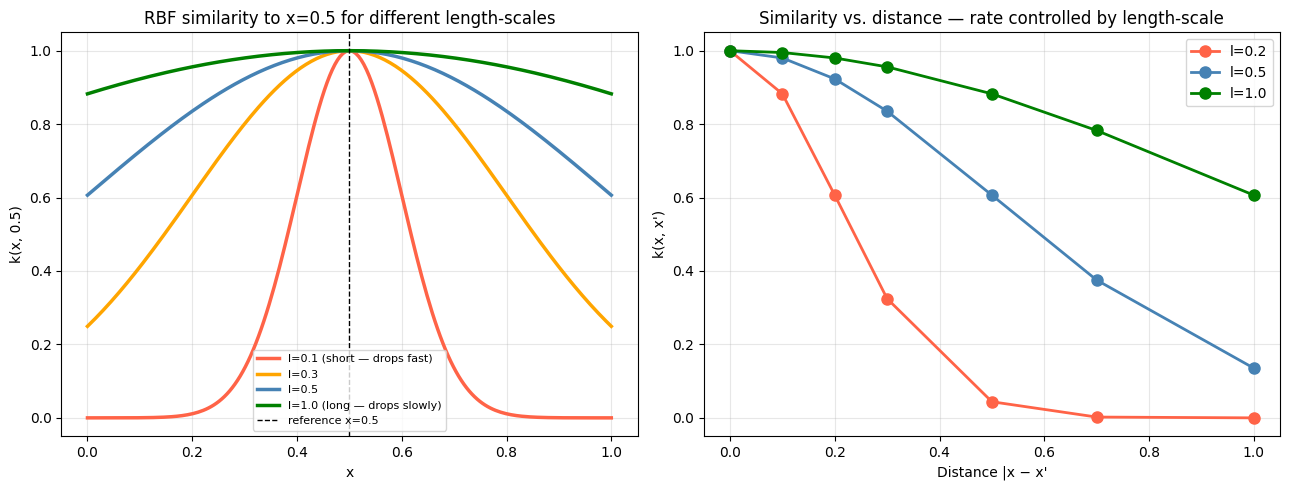

In [4]:
x_ref   = np.array([[0.5]])
x_query = np.linspace(0, 1, 200).reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ls, color, label in [(0.1, 'tomato', 'l=0.1 (short — drops fast)'),
                          (0.3, 'orange', 'l=0.3'),
                          (0.5, 'steelblue', 'l=0.5'),
                          (1.0, 'green', 'l=1.0 (long — drops slowly)')]:
    k_vals = rbf(x_query, x_ref, length_scale=ls).squeeze()
    axes[0].plot(x_query.squeeze(), k_vals, color=color, linewidth=2.5, label=label)

axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1, label='reference x=0.5')
axes[0].set_title('RBF similarity to x=0.5 for different length-scales')
axes[0].set_xlabel('x')
axes[0].set_ylabel("k(x, 0.5)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

distances = np.array([0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0])
for ls, color in [(0.2, 'tomato'), (0.5, 'steelblue'), (1.0, 'green')]:
    k_vals = rbf(np.zeros((len(distances), 1)),
                 distances.reshape(-1, 1), length_scale=ls).diagonal()
    axes[1].plot(distances, k_vals, 'o-', color=color, linewidth=2,
                 markersize=8, label=f'l={ls}')

axes[1].set_title('Similarity vs. distance — rate controlled by length-scale')
axes[1].set_xlabel('Distance |x − x\'')
axes[1].set_ylabel("k(x, x')")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Key insight:** The length-scale determines how far apart two points need to be before the GP treats them as unrelated. A short length-scale = the surrogate only trusts very nearby observations.

---
## Part 2 — The Kernel Matrix

Given n training points, the **kernel matrix** K is an n×n matrix where:

$$K_{ij} = k(x_i, x_j)$$

Properties:
- Always symmetric: K = Kᵀ
- Diagonal is always 1.0 (each point is perfectly similar to itself when σ²=1)
- Must be positive semi-definite (so we can take its Cholesky factor)

The GP uses this matrix to compute posterior predictions — it tells the GP how much each training point should influence each prediction.

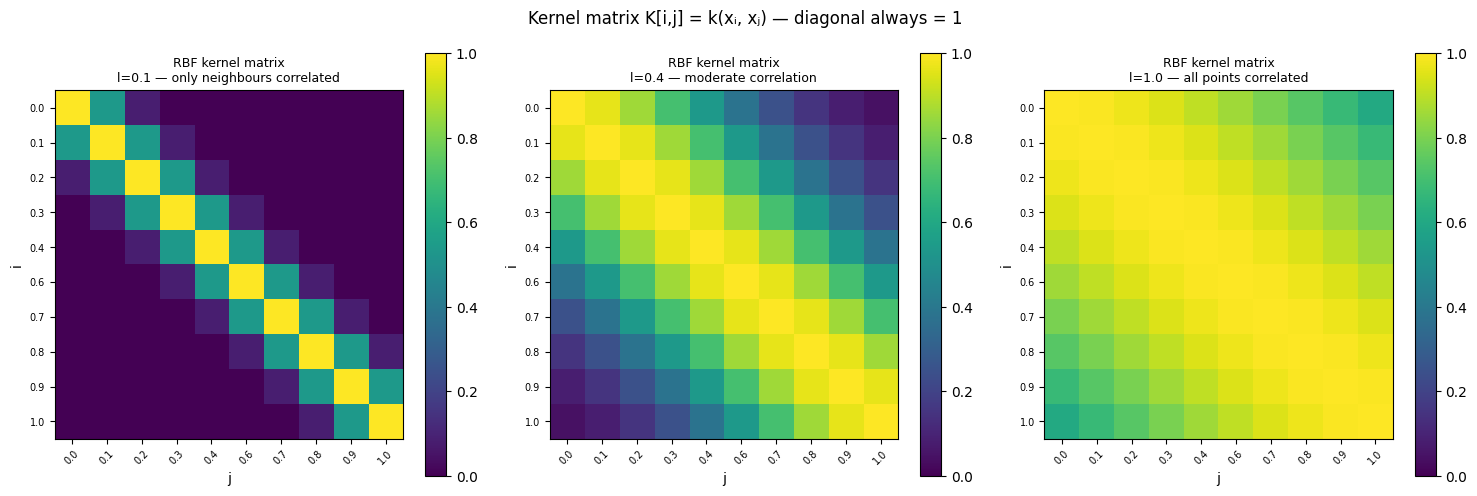

In [5]:
x_pts = np.linspace(0, 1, 10).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, ls, title in zip(
    axes,
    [0.1, 0.4, 1.0],
    ['l=0.1 — only neighbours correlated',
     'l=0.4 — moderate correlation',
     'l=1.0 — all points correlated']
):
    K = rbf(x_pts, x_pts, length_scale=ls)
    im = ax.imshow(K, cmap='viridis', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax)
    ax.set_title(f'RBF kernel matrix\n{title}', fontsize=9)
    ax.set_xlabel('j')
    ax.set_ylabel('i')
    labels = [f'{v:.1f}' for v in x_pts.squeeze()]
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    ax.set_xticklabels(labels, rotation=45, fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)

plt.suptitle('Kernel matrix K[i,j] = k(xᵢ, xⱼ) — diagonal always = 1', fontsize=12)
plt.tight_layout()
plt.show()

With a short length-scale, only neighbouring points have high similarity (bright cells near the diagonal). With a long length-scale, all points are correlated (the whole matrix is bright).

**Try it:** Print `K` for l=0.1. Verify that K[0,0]=1.0 and K[0,9] ≈ 0.0.

---
## Part 3 — Sampling Functions from a GP Prior

Before seeing any data, a GP defines a distribution over functions — the **GP prior**.
We can sample from it using the kernel matrix:

1. Build K = kernel matrix over a dense grid of x points
2. Compute the Cholesky factor L such that K = LLᵀ
3. Sample z ~ N(0, I)
4. f = L @ z  →  f ~ N(0, K)

Different kernels produce different styles of functions.

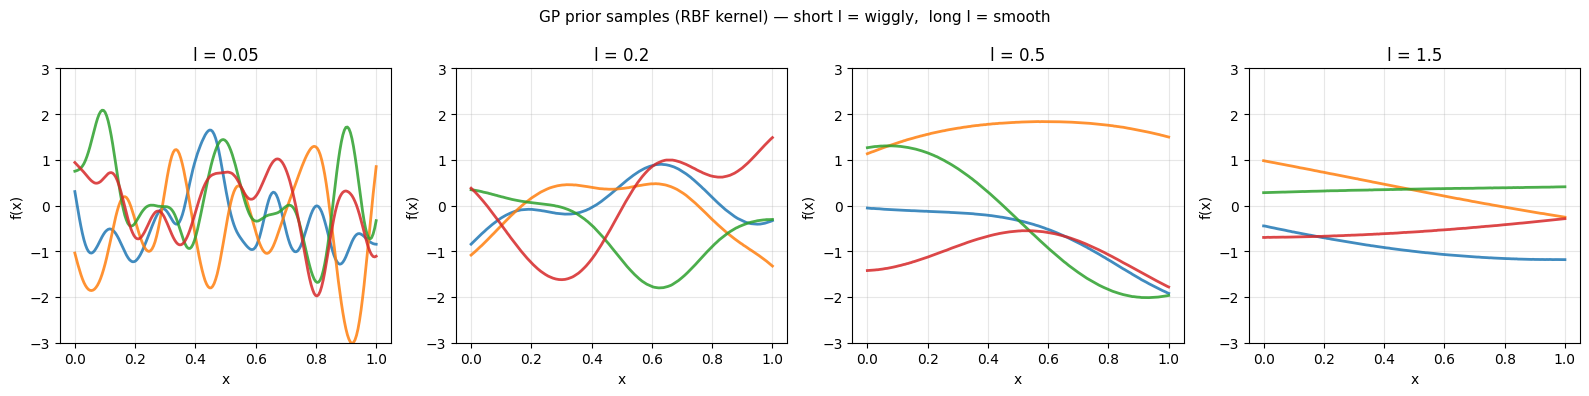

In [6]:
def sample_gp_prior(K, n_samples=5, jitter=1e-6):
    K_jit = K + jitter * np.eye(len(K))
    L = np.linalg.cholesky(K_jit)
    z = rng.standard_normal((len(K), n_samples))
    return L @ z

x_fine = np.linspace(0, 1, 200).reshape(-1, 1)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, ls in zip(axes, [0.05, 0.2, 0.5, 1.5]):
    K = rbf(x_fine, x_fine, length_scale=ls)
    samples = sample_gp_prior(K, n_samples=4)
    for i in range(4):
        ax.plot(x_fine.squeeze(), samples[:, i], linewidth=2, alpha=0.85)
    ax.set_title(f'l = {ls}')
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_ylim(-3, 3)
    ax.grid(True, alpha=0.3)

plt.suptitle('GP prior samples (RBF kernel) — short l = wiggly,  long l = smooth', fontsize=11)
plt.tight_layout()
plt.show()

Each coloured line is one sample from the GP prior — a plausible function given the kernel. The GP posterior (after seeing data) will concentrate these samples around the observed values.

**Try it:** Change `l=0.05` to `l=0.01`. What happens? Is this a useful surrogate for most engineering functions?

---
## Part 4 — Kernel Comparison

Three kernels you will see in papers:

| Kernel | Formula | Differentiability | When to use |
|---|---|---|---|
| RBF | exp(−r²/2l²) | Infinitely | Extremely smooth functions |
| Matern-5/2 | (1+√5r/l+(5r²/3l²))exp(−√5r/l) | Twice | Most engineering functions |
| Matern-3/2 | (1+√3r/l)exp(−√3r/l) | Once | Rougher functions |
| Linear | xᵀx' | N/A | When you expect a linear trend |

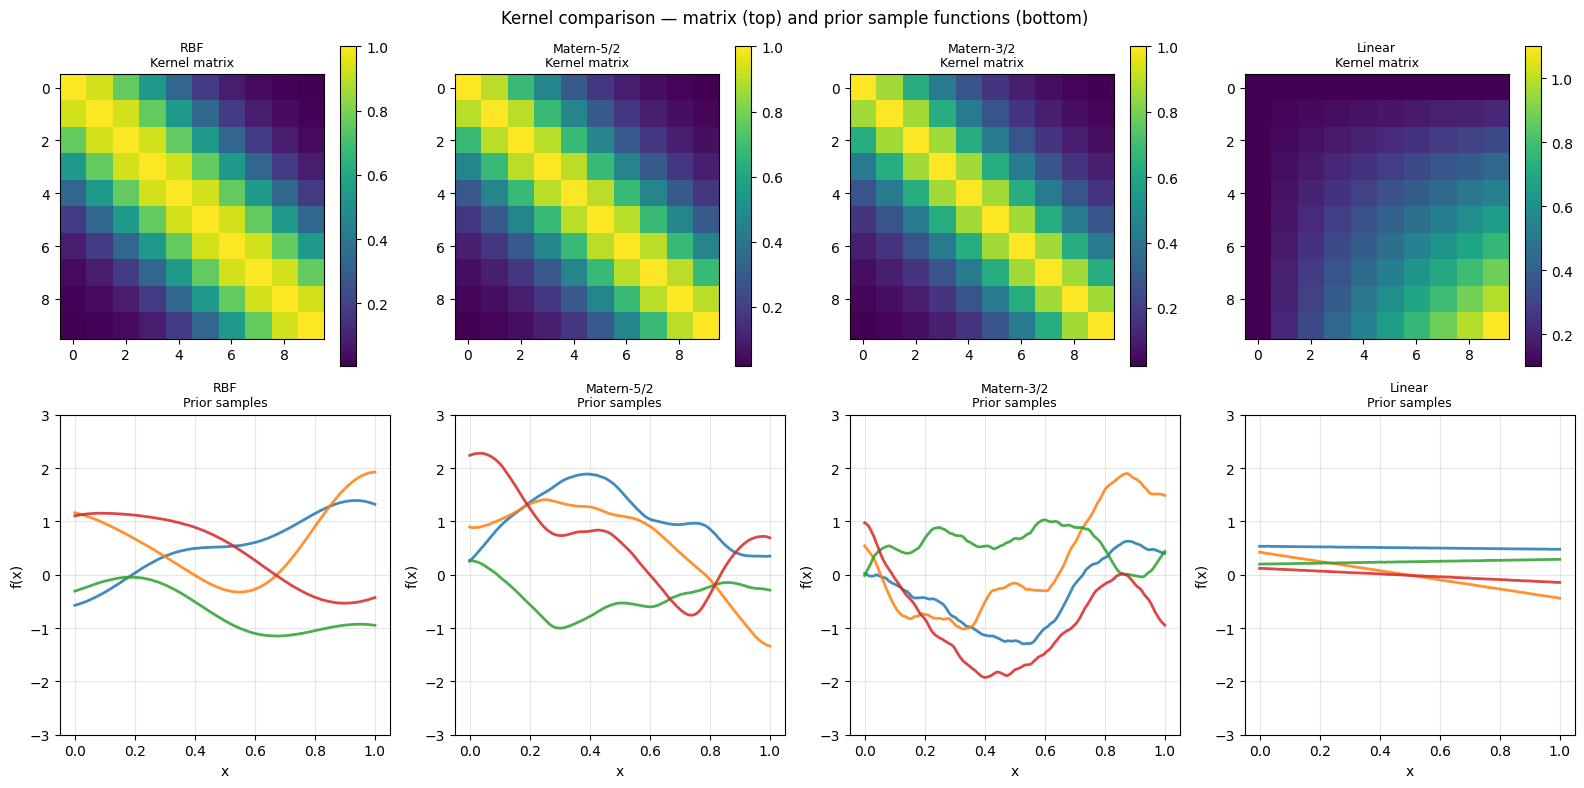

In [7]:
def matern52(X1, X2, length_scale=1.0, signal_var=1.0):
    X1 = np.atleast_2d(X1)
    X2 = np.atleast_2d(X2)
    r = np.sqrt(np.sum((X1[:, None, :] - X2[None, :, :])**2, axis=-1))
    s = np.sqrt(5) * r / length_scale
    return signal_var * (1 + s + s**2 / 3) * np.exp(-s)

def matern32(X1, X2, length_scale=1.0, signal_var=1.0):
    X1 = np.atleast_2d(X1)
    X2 = np.atleast_2d(X2)
    r = np.sqrt(np.sum((X1[:, None, :] - X2[None, :, :])**2, axis=-1))
    s = np.sqrt(3) * r / length_scale
    return signal_var * (1 + s) * np.exp(-s)

def linear_kernel(X1, X2, signal_var=1.0, bias=0.1):
    X1 = np.atleast_2d(X1)
    X2 = np.atleast_2d(X2)
    return signal_var * (X1 @ X2.T) + bias

kernels = [
    ('RBF',        lambda a, b: rbf(a, b, length_scale=0.3)),
    ('Matern-5/2', lambda a, b: matern52(a, b, length_scale=0.3)),
    ('Matern-3/2', lambda a, b: matern32(a, b, length_scale=0.3)),
    ('Linear',     lambda a, b: linear_kernel(a, b)),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col, (name, kern_fn) in enumerate(kernels):
    # Kernel matrix
    K_mat = kern_fn(x_pts, x_pts)
    im = axes[0, col].imshow(K_mat, cmap='viridis')
    plt.colorbar(im, ax=axes[0, col])
    axes[0, col].set_title(f'{name}\nKernel matrix', fontsize=9)

    # Prior samples
    K_fine = kern_fn(x_fine, x_fine)
    try:
        samples = sample_gp_prior(K_fine, n_samples=4)
        for i in range(4):
            axes[1, col].plot(x_fine.squeeze(), samples[:, i], linewidth=2, alpha=0.85)
    except np.linalg.LinAlgError:
        axes[1, col].text(0.5, 0.5, 'Not PSD', ha='center',
                          transform=axes[1, col].transAxes)

    axes[1, col].set_title(f'{name}\nPrior samples', fontsize=9)
    axes[1, col].set_xlabel('x')
    axes[1, col].set_ylabel('f(x)')
    axes[1, col].set_ylim(-3, 3)
    axes[1, col].grid(True, alpha=0.3)

plt.suptitle('Kernel comparison — matrix (top) and prior sample functions (bottom)', fontsize=12)
plt.tight_layout()
plt.show()

Observations:
- **RBF** — smoothest functions, never has a kink
- **Matern-5/2** — nearly as smooth, but allows slight roughness → preferred in practice
- **Matern-3/2** — visibly rougher, more realistic for some engineering functions
- **Linear** — all sampled functions are straight lines → only useful when you expect linear behaviour

**Try it:** Add noise `K += 0.01 * np.eye(n)` before sampling. How does this affect the samples?

---
## Part 5 — Same Data, Different Kernel

Kernel choice affects not just smoothness but also uncertainty bands — especially between data points.

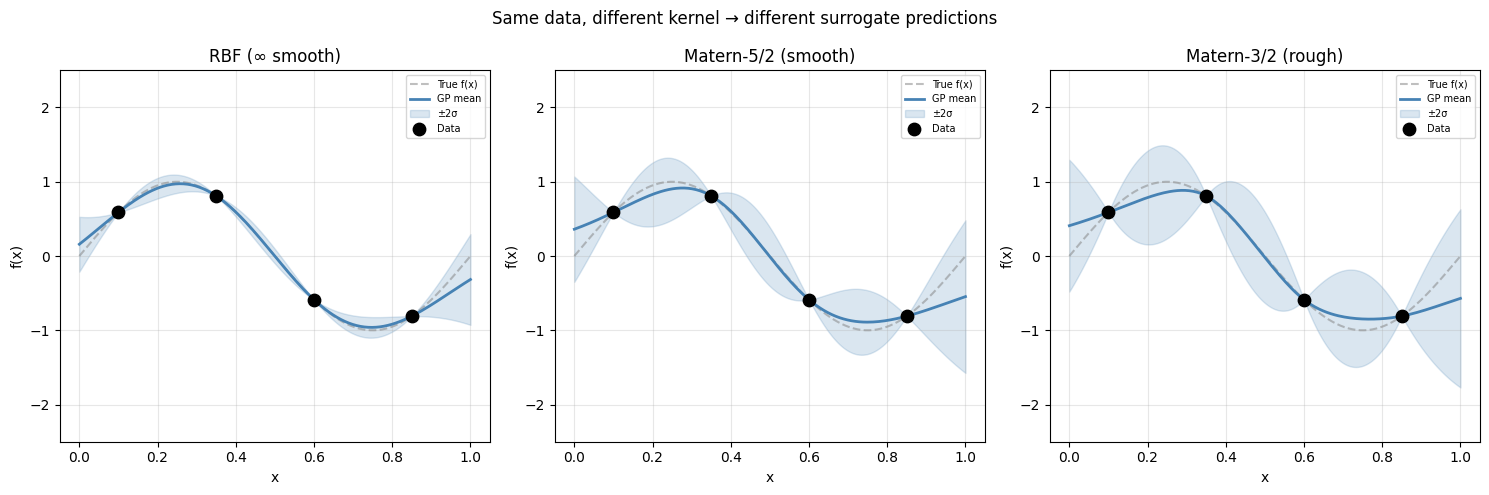

In [8]:
x_obs = np.array([[0.1], [0.35], [0.6], [0.85]])
y_obs = np.sin(2 * np.pi * x_obs.squeeze())

kern_compare = [
    ('RBF (∞ smooth)',      lambda a, b: rbf(a, b, length_scale=0.3)),
    ('Matern-5/2 (smooth)', lambda a, b: matern52(a, b, length_scale=0.3)),
    ('Matern-3/2 (rough)',  lambda a, b: matern32(a, b, length_scale=0.3)),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, kern_fn) in zip(axes, kern_compare):
    K   = kern_fn(x_obs, x_obs) + 1e-6 * np.eye(len(x_obs))
    Ks  = kern_fn(x_fine, x_obs)
    Kss = kern_fn(x_fine, x_fine)
    L   = np.linalg.cholesky(K)
    mu  = Ks @ np.linalg.solve(L.T, np.linalg.solve(L, y_obs))
    v   = np.linalg.solve(L, Ks.T)
    std = np.sqrt(np.maximum(np.diag(Kss) - np.sum(v**2, axis=0), 0))

    ax.plot(x_fine.squeeze(), np.sin(2*np.pi*x_fine.squeeze()),
            'gray', linewidth=1.5, linestyle='--', label='True f(x)', alpha=0.5)
    ax.plot(x_fine.squeeze(), mu, 'steelblue', linewidth=2, label='GP mean')
    ax.fill_between(x_fine.squeeze(), mu - 2*std, mu + 2*std,
                    alpha=0.2, color='steelblue', label='±2σ')
    ax.scatter(x_obs.squeeze(), y_obs, color='black', s=80, zorder=5, label='Data')
    ax.set_title(name)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_ylim(-2.5, 2.5)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Same data, different kernel → different surrogate predictions', fontsize=12)
plt.tight_layout()
plt.show()

**Try it:** Change `length_scale=0.3` to `length_scale=0.1` in all three. What happens to the uncertainty bands between the observed points?

---
## Part 6 — Kernels in 2D and the NN Alternative

For a 2D problem (like Branin or BBOB functions), the kernel takes two 2D points:
$$k(\mathbf{x}, \mathbf{x}') = \sigma^2 \exp\left(-\frac{\|\mathbf{x} - \mathbf{x}'\|^2}{2l^2}\right)$$

The distance is now Euclidean distance in 2D — same formula, higher input dimension.

**The GP scaling problem:**
- For n training points in d dimensions, the kernel matrix is n×n — still O(n³) to invert
- But with a single length-scale l, the kernel treats all dimensions equally
- If some dimensions matter more than others, a single l is not enough

**Why neural networks win in high dimensions:**
- No kernel matrix to invert — O(n) scaling
- The network **learns** which dimensions matter through its weights
- Equivalent to having a separate length-scale per dimension — for free

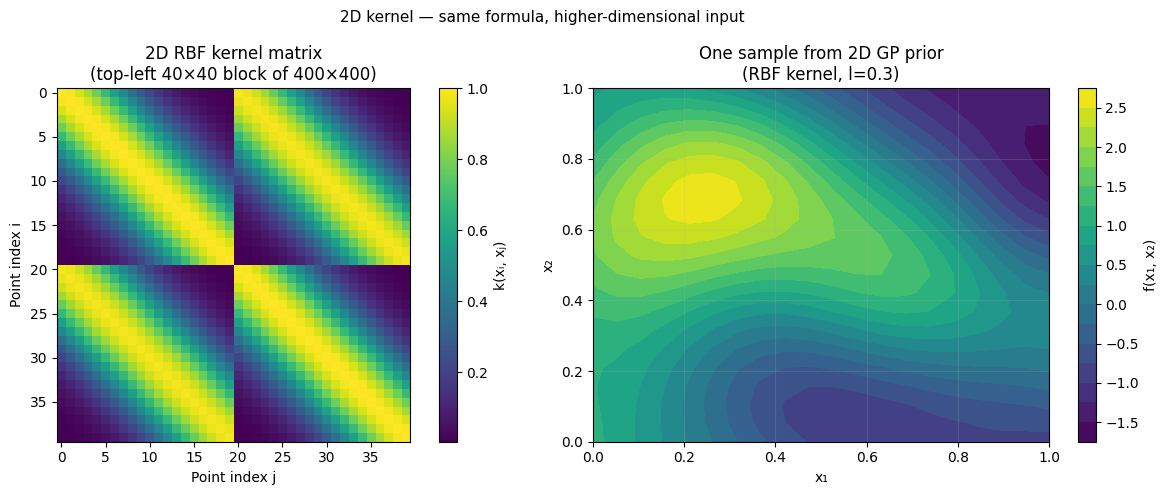

Kernel matrix size: (400, 400)  (160,000 entries)
Inverting this: O(n³) = O(400³) = 64,000,000 operations
At d=40 (BBOB), n=1000 points: 1,000³ = 10^9 operations — slow!
Neural networks: O(n) — this is why NNs scale better (Lessons 10-11)


In [9]:
# Build a 2D grid and sample one function from the GP prior
x1_grid = np.linspace(0, 1, 20)
x2_grid = np.linspace(0, 1, 20)
X1g, X2g = np.meshgrid(x1_grid, x2_grid)
X2d = np.column_stack([X1g.ravel(), X2g.ravel()])  # 400 points in 2D

K_2d = rbf(X2d, X2d, length_scale=0.3)
sample_2d = sample_gp_prior(K_2d, n_samples=1)[:, 0].reshape(20, 20)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im = axes[0].imshow(K_2d[:40, :40], cmap='viridis')  # show top-left corner
plt.colorbar(im, ax=axes[0], label='k(xᵢ, xⱼ)')
axes[0].set_title('2D RBF kernel matrix\n(top-left 40×40 block of 400×400)')
axes[0].set_xlabel('Point index j')
axes[0].set_ylabel('Point index i')

cf = axes[1].contourf(X1g, X2g, sample_2d, levels=20, cmap='viridis')
plt.colorbar(cf, ax=axes[1], label='f(x₁, x₂)')
axes[1].set_title('One sample from 2D GP prior\n(RBF kernel, l=0.3)')
axes[1].set_xlabel('x₁')
axes[1].set_ylabel('x₂')
axes[1].grid(True, alpha=0.2)

plt.suptitle('2D kernel — same formula, higher-dimensional input', fontsize=11)
plt.tight_layout()
plt.show()

print(f'Kernel matrix size: {K_2d.shape}  ({K_2d.shape[0]*K_2d.shape[1]:,} entries)')
print(f'Inverting this: O(n³) = O({K_2d.shape[0]}³) = {K_2d.shape[0]**3:,} operations')
print('At d=40 (BBOB), n=1000 points: 1,000³ = 10^9 operations — slow!')
print('Neural networks: O(n) — this is why NNs scale better (Lessons 10-11)')

---
## Summary

| Kernel | Smoothness | Typical use |
|---|---|---|
| RBF | Infinitely smooth | Very smooth functions, can oversmooth |
| Matern-5/2 | Twice differentiable | **Default choice in practice** |
| Matern-3/2 | Once differentiable | Rougher real-world functions |
| Linear | Not smooth | When linear trend is expected |

**The neural network advantage:**
- No kernel = no O(n³) matrix inversion
- Learns similarity automatically from data
- Handles high dimensions and irrelevant features naturally

---

## Exercises

1. In Part 3, set `length_scale=0.01`. What happens to the prior samples? Would this GP make useful predictions?
2. In Part 4, add `K += 0.01 * np.eye(len(K_fine))` before sampling. How do the functions change? (Hint: this is how a noisy GP works.)
3. Implement the **periodic kernel**: `k(x,x') = σ² exp(−2 sin²(π|x−x'|/p) / l²)`. Sample functions from it. What do they look like?

---

## What's Next

**Lesson 6** — Gaussian Process regression. You will combine the conditional distribution formula from Lesson 4 with the kernel matrix from this lesson to build a complete GP surrogate from scratch — and use it as the baseline model your neural network will be compared against.